In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# **LOAD DATA**

In [ ]:
df = pd.read_csv('Realestate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


# **INFORMASI DATA**

In [ ]:
df.shape

(414, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


# **CLEANING**

In [ ]:
#mengubah representasi tanggal dalam float menjadi integer untuk mengambil bagian
df['X1 transaction date']=df['X1 transaction date'].astype(int)
# df.transaction_date = df.transaction_date.astype()

In [ ]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [ ]:
#Ubah nama kolom
new_names = ['No','transaction_date','house_age','dist_to_MRT','conv_store','lat','long','house_price']
df = df.set_axis(new_names, axis="columns")

In [ ]:
df.set_index('No')

,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
No,,,,,,,
1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
410,2013,13.7,4082.01500,0,24.94155,121.50381,15.4
411,2012,5.6,90.45606,9,24.97433,121.54310,50.0
412,2013,18.8,390.96960,7,24.97923,121.53986,40.6


In [ ]:
print(df.nunique())

No                  414
transaction_date      2
house_age           236
dist_to_MRT         259
conv_store           11
lat                 234
long                232
house_price         270
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                414 non-null    int64  
 1   transaction_date  414 non-null    int64  
 2   house_age         414 non-null    float64
 3   dist_to_MRT       414 non-null    float64
 4   conv_store        414 non-null    int64  
 5   lat               414 non-null    float64
 6   long              414 non-null    float64
 7   house_price       414 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 26.0 KB


In [ ]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
409    False
410    False
411    False
412    False
413    False
Length: 414, dtype: bool

In [ ]:
#Cek Nilai Null
df.isnull().sum()

No                  0
transaction_date    0
house_age           0
dist_to_MRT         0
conv_store          0
lat                 0
long                0
house_price         0
dtype: int64

In [ ]:
dups=df.duplicated()
print(dups.any())

False


In [ ]:
print(df.nunique())

No                  414
transaction_date      2
house_age           236
dist_to_MRT         259
conv_store           11
lat                 234
long                232
house_price         270
dtype: int64


In [ ]:
new_names = ['No','transaction_date','house_age','dist_to_MRT','conv_store','lat','long','house_price']
df = df.set_axis(new_names, axis="columns")

# **SETELAH CLEANING**

In [ ]:
df.describe()

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2012.695652,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.460687,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.000000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.000000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.000000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.000000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.000000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
#Cek Korelasi
df.corr()

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
No,1.000000,0.007379,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
transaction_date,0.007379,1.000000,0.049171,0.016519,-0.005586,0.008118,0.013177,0.081545
house_age,-0.032808,0.049171,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
dist_to_MRT,-0.013573,0.016519,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
conv_store,-0.012699,-0.005586,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
lat,-0.010110,0.008118,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
long,-0.011059,0.013177,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
house_price,-0.028587,0.081545,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


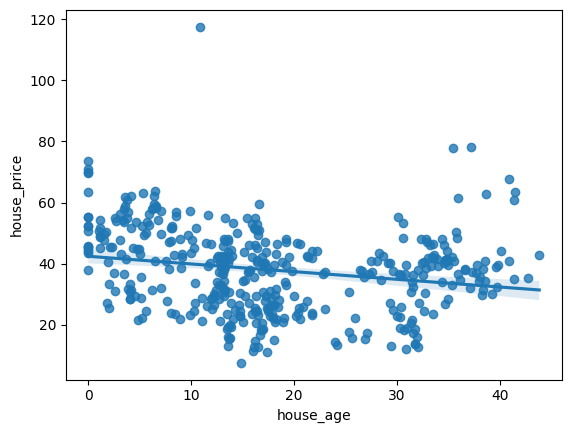

In [ ]:
sns.regplot(x="house_age", y="house_price", data=df);

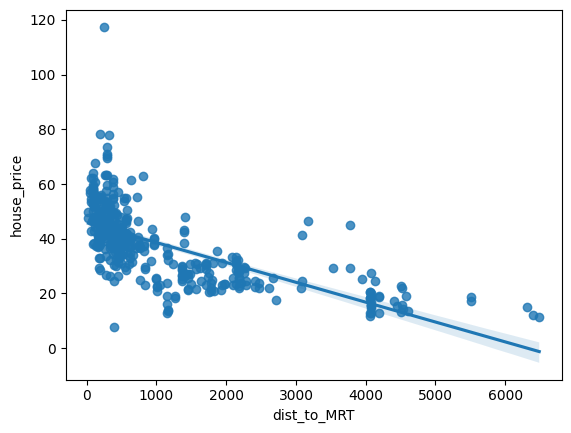

In [ ]:
sns.regplot(x="dist_to_MRT", y="house_price", data=df);

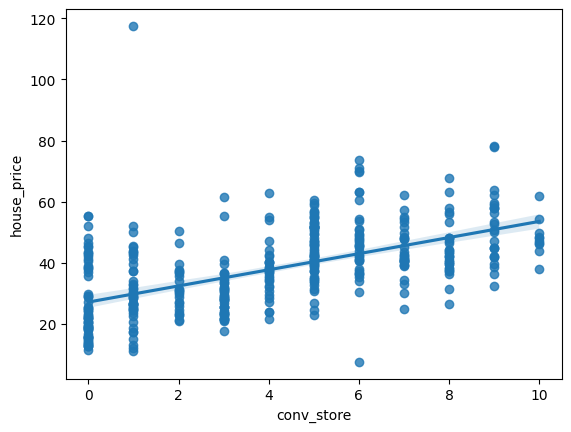

In [ ]:
sns.regplot(x="conv_store", y="house_price", data=df);

# **BOXPLOT**

<Axes: >

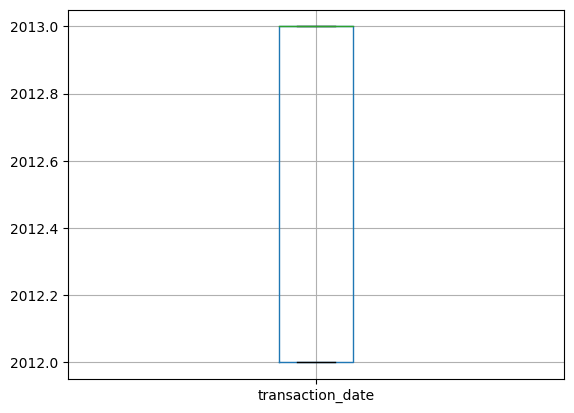

In [ ]:
df.boxplot(column=['transaction_date'])

<Axes: >

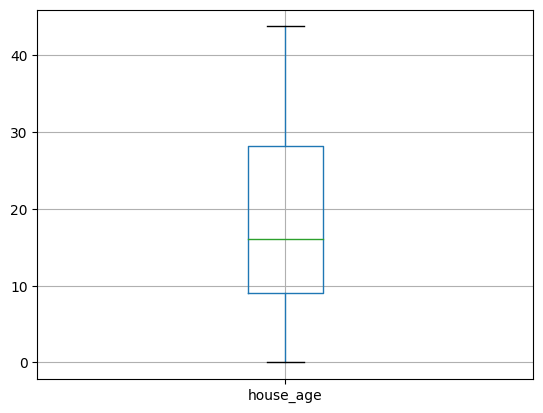

In [ ]:
df.boxplot(column=['house_age'])

<Axes: >

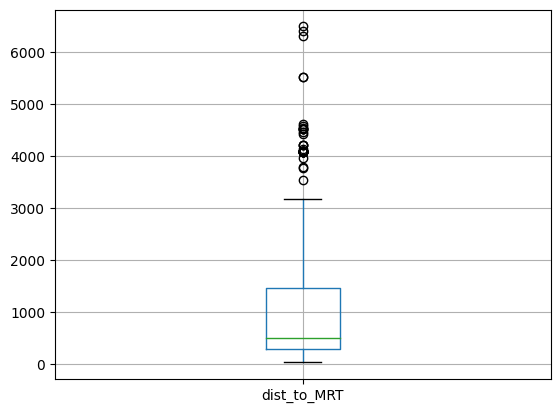

In [ ]:
df.boxplot(column=['dist_to_MRT'])

<Axes: >

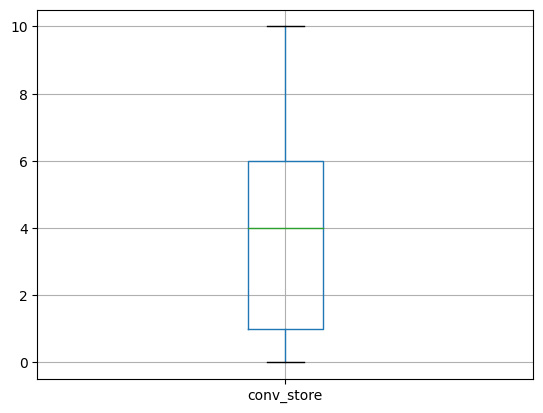

In [ ]:
df.boxplot(column=['conv_store'])

<Axes: >

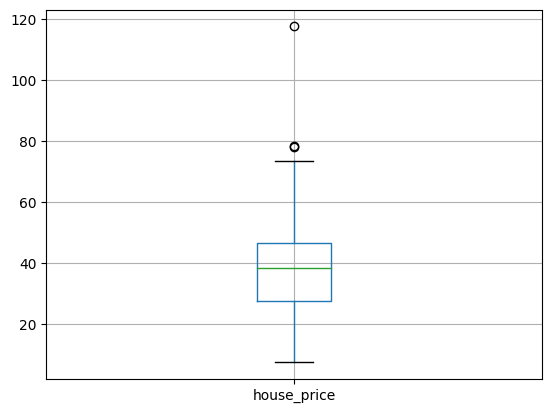

In [ ]:
df.boxplot(column=['house_price'])

# **HAPUS OUTLIER**

In [ ]:
Q1 = df.dist_to_MRT.quantile(0.25)
Q3 = df.dist_to_MRT.quantile(0.75)
IQR = Q3 - Q1
df_1 = df[~((df.dist_to_MRT < (Q1 - 1.5 * IQR)) | (df.dist_to_MRT > (Q3 +1.5 *IQR)))]
print(df.shape)
print(df_1.shape)

(414, 8)
(377, 8)


In [ ]:
Q1 = df_1.lat.quantile(0.25)
Q3 = df_1.lat.quantile(0.75)
IQR = Q3 - Q1
df_2 = df_1[~((df_1.lat < (Q1 - 1.5 * IQR)) | (df_1.lat > (Q3 + 1.5 * IQR)))]
print(df_1.shape)
print(df_2.shape)

(377, 8)
(376, 8)


In [ ]:
Q1 = df_2.long.quantile(0.25)
Q3 = df_2.long.quantile(0.75)
IQR = Q3 - Q1
df_3 = df_2[~((df_2.long < (Q1 - 1.5 * IQR)) | (df_2.long > (Q3 + 1.5 * IQR)))]
print(df_2.shape)
print(df_3.shape)

(376, 8)
(315, 8)


In [ ]:
Q1 = df_3.house_price.quantile(0.25)
Q3 = df_3.house_price.quantile(0.75)
IQR = Q3 - Q1
df_4 = df_3[~((df_3.house_price < (Q1 - 1.5 * IQR)) | (df_3.house_price > (Q3 + 1.5 * IQR)))]
print(df_3.shape)
print(df_4.shape)

(315, 8)
(303, 8)


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_5 = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df.shape)
print(df_5.shape)

(414, 8)
(371, 8)


In [ ]:
df_5.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 371 entries, 0 to 413
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                371 non-null    int64  
 1   transaction_date  371 non-null    int64  
 2   house_age         371 non-null    float64
 3   dist_to_MRT       371 non-null    float64
 4   conv_store        371 non-null    int64  
 5   lat               371 non-null    float64
 6   long              371 non-null    float64
 7   house_price       371 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 26.1 KB


In [ ]:
df.columns

Index(['No', 'transaction_date', 'house_age', 'dist_to_MRT', 'conv_store',
       'lat', 'long', 'house_price'],
      dtype='object')

# **PERBANDINGAN SETELAH HAPUS OUTLIER**

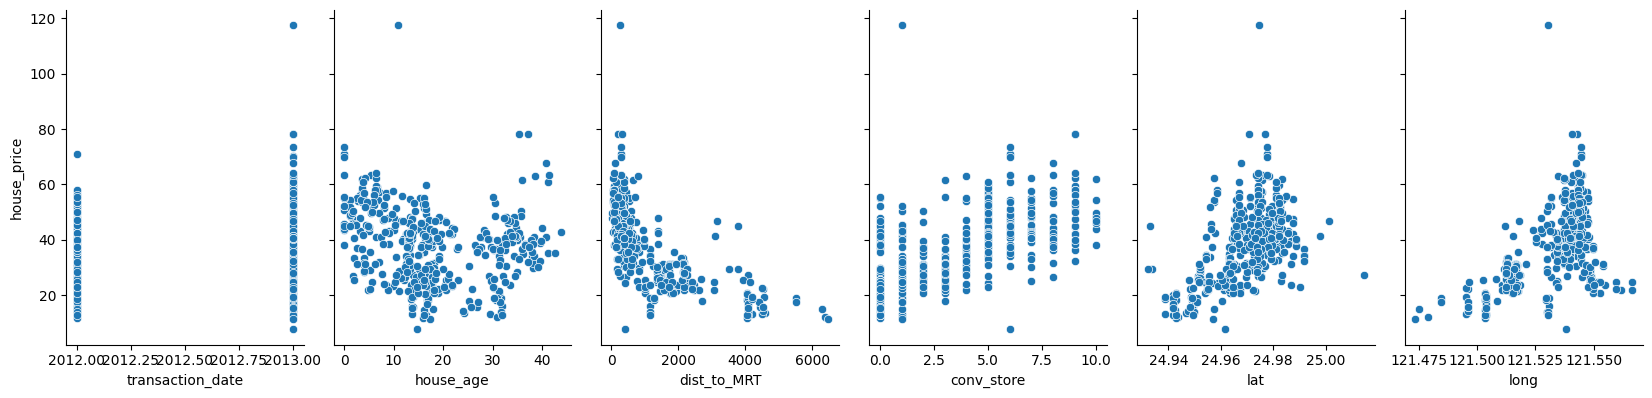

In [ ]:
p = sns.pairplot(df, x_vars=['transaction_date','house_age','dist_to_MRT','conv_store','lat','long'], y_vars='house_price', height=4, aspect=0.7)

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


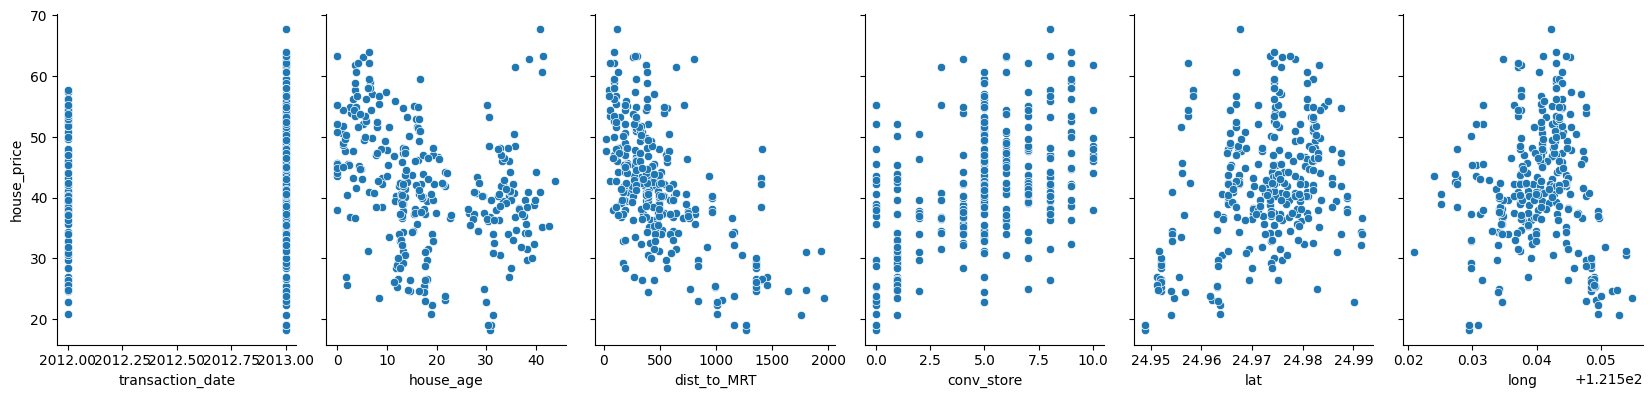

In [ ]:
p = sns.pairplot(df_4, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', size=4, aspect=0.7)

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


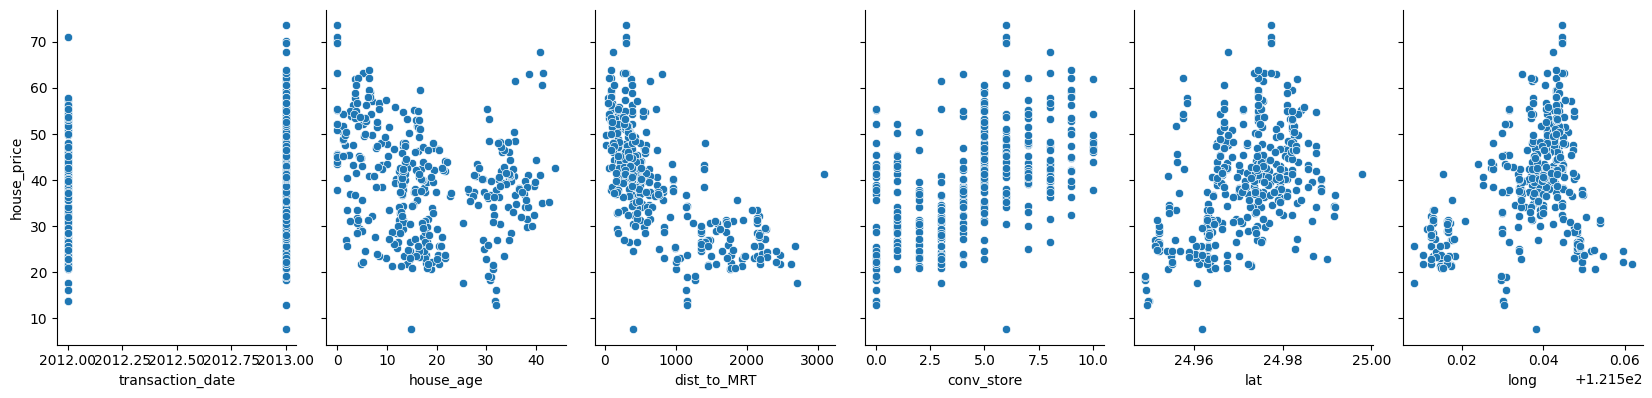

In [ ]:
p = sns.pairplot(df_5, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', size=4, aspect=0.7)

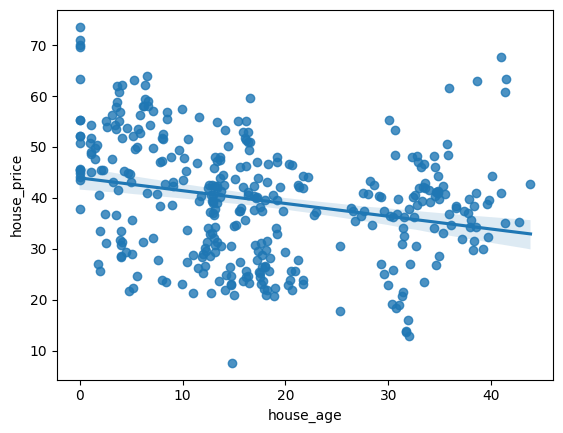

In [ ]:
sns.regplot(x='house_age', y= 'house_price', data=df_5);

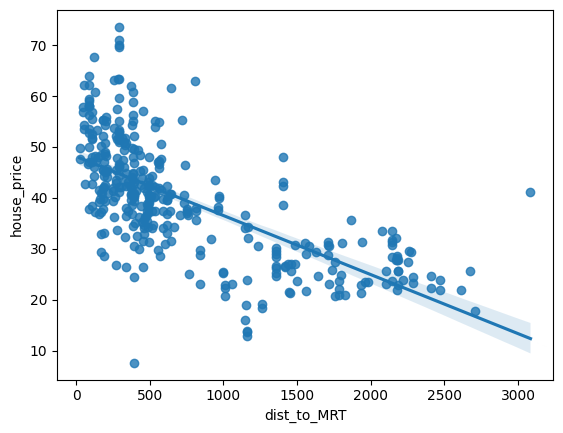

In [ ]:
sns.regplot(x='dist_to_MRT', y= 'house_price', data=df_5);

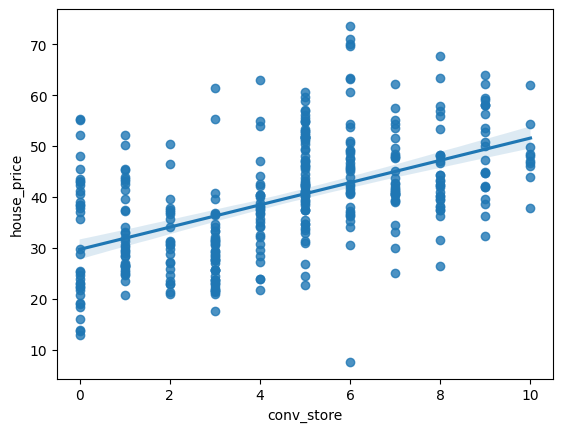

In [ ]:
sns.regplot(x='conv_store', y= 'house_price', data=df_5);

In [ ]:
df

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
0,1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013,8.1,104.81010,5,24.96674,121.54067,52.5


# **CLUSTERING**

In [ ]:
df_model_house_age_l_20 = df[df['house_age'] < 20]
df_model_house_age_m_20 = df[df['house_age'] > 20]

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


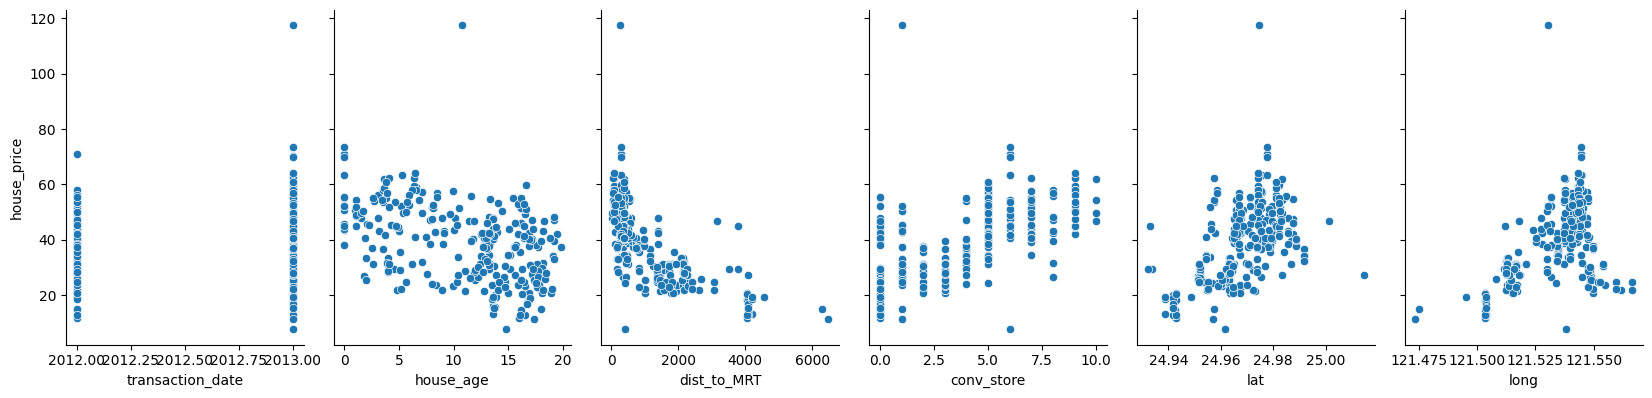

In [ ]:
p = sns.pairplot(df_model_house_age_l_20, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', size=4, aspect=0.7)

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


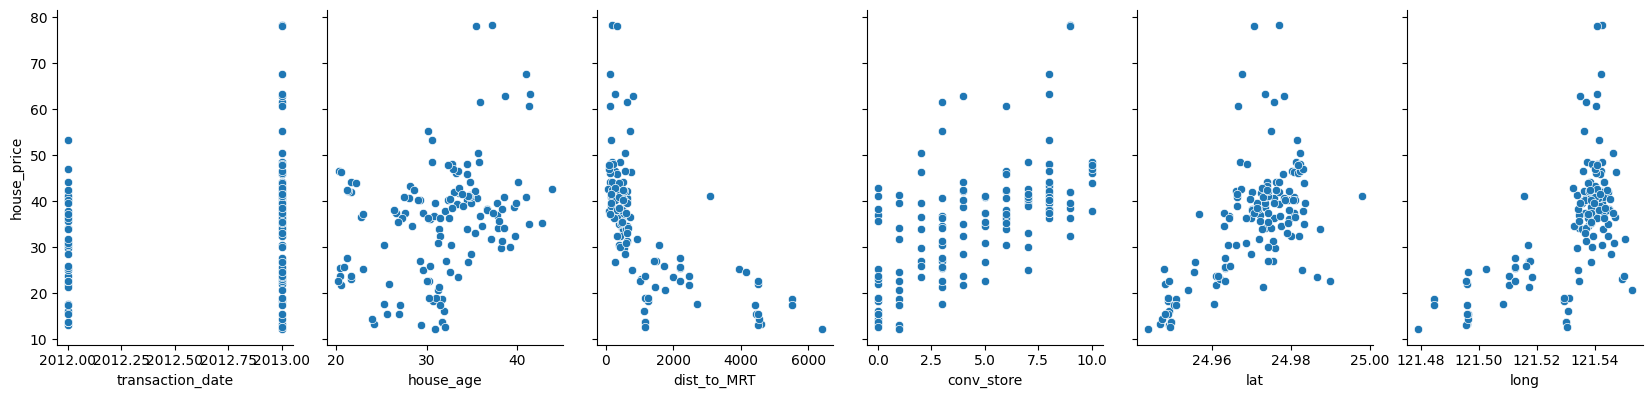

In [ ]:
p = sns.pairplot(df_model_house_age_m_20, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', size=4, aspect=0.7)

# **CEK KORELASI**

<Axes: >

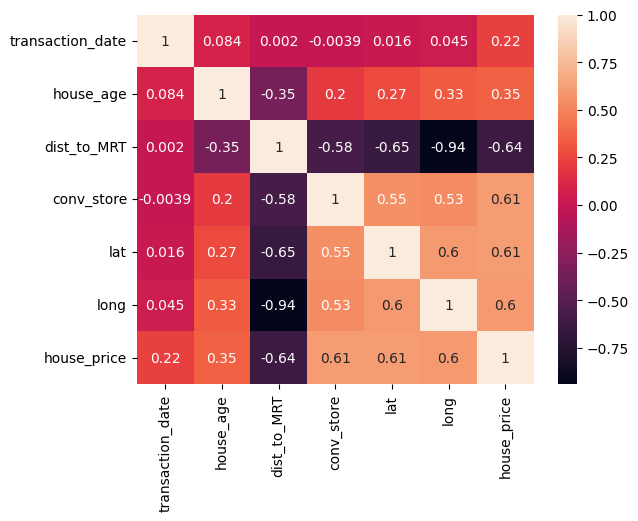

In [ ]:
sns.heatmap(df_model_house_age_m_20.drop(columns=['No']).corr(), annot= True)

<Axes: >

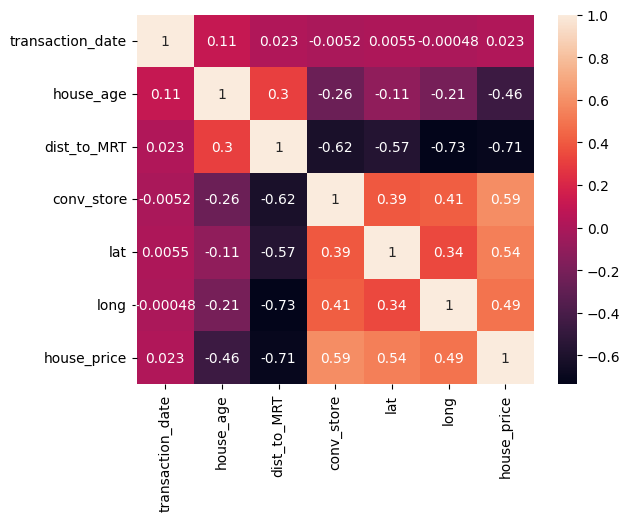

In [ ]:
sns.heatmap(df_model_house_age_l_20.drop(columns=['No']).corr(), annot= True)

<Axes: >

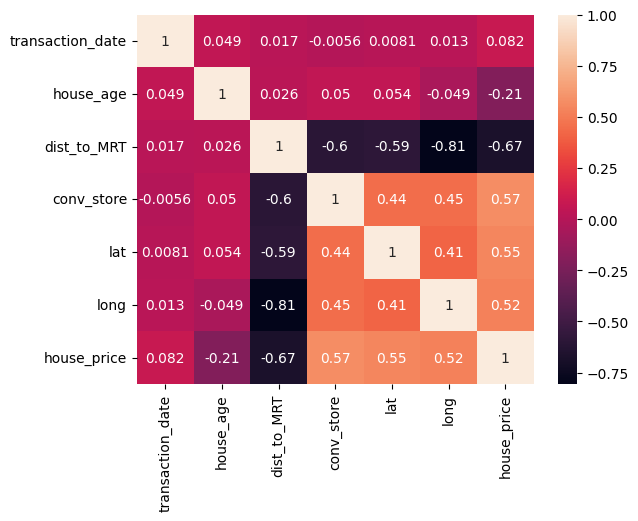

In [ ]:
sns.heatmap(df.drop(columns=['No']).corr(), annot= True)

<Axes: >

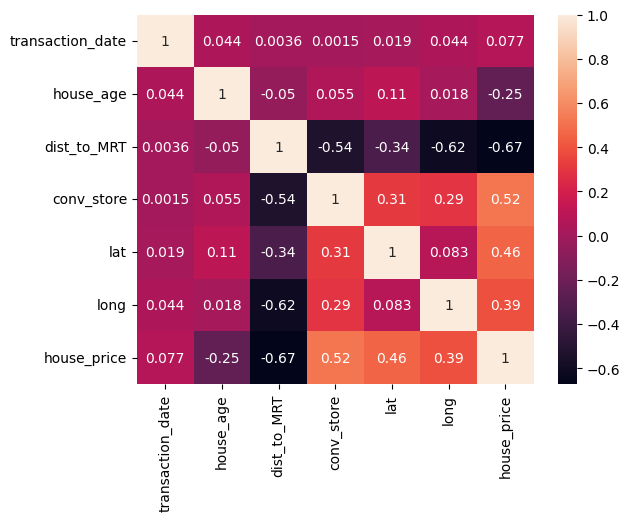

In [ ]:
sns.heatmap(df_5.drop(columns=['No']).corr(), annot= True)

# **TAMPILKAN MAP**

In [ ]:
price_description = df_4['house_price'].describe()
print(price_description)

count    303.000000
mean      42.077228
std        9.902634
min       18.300000
25%       36.500000
50%       41.900000
75%       48.350000
max       67.700000
Name: house_price, dtype: float64


In [ ]:
import folium

# Inisialisasi peta dengan koordinat tengah (misalnya, rata-rata latitude dan longitude)
LAT = df_4['lat']
LONG = df_4['long']
CPRICE = df_4['house_price']
peta = folium.Map(location=[LAT.mean(), LONG.mean()], zoom_start=15)

# Tentukan rentang warna yang akan digunakan (misalnya, dari hijau ke merah)
colors = ['green', 'green', 'yellow', 'red']

# Tentukan rentang nilai untuk kolom house_price (anda bisa sesuaikan sesuai data yang sesungguhnya)
price_ranges = [0, 20, 40, 50, float('inf')]

# Tambahkan penanda untuk setiap titik data dengan warna yang sesuai
for i in range(len(LAT)):
    for j in range(len(price_ranges) - 1):
        if price_ranges[j] <= df_4['house_price'].iloc[i] < price_ranges[j+1]:
            folium.CircleMarker(
                location=[LAT.iloc[i], LONG.iloc[i]],
                radius=5,  # Ukuran marker
                color=colors[j],  # Warna marker
                fill=True,
                fill_color=colors[j],
                fill_opacity=0.6,
                popup=f'Harga Rumah: {df_4["house_price"].iloc[i]:.2f}'  # Popup informasi
            ).add_to(peta)

# Tampilkan peta
peta

# **NORMALISASI**

<ipython-input-51-e75b3f751c41>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_4['sqrt_dist_to_MRT'] = np.sqrt(df_4['dist_to_MRT'])
<ipython-input-51-e75b3f751c41>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_4['sqrt_house_price'] = np.sqrt(df_4['house_price'])
<ipython-input-51-e75b3f751c41>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

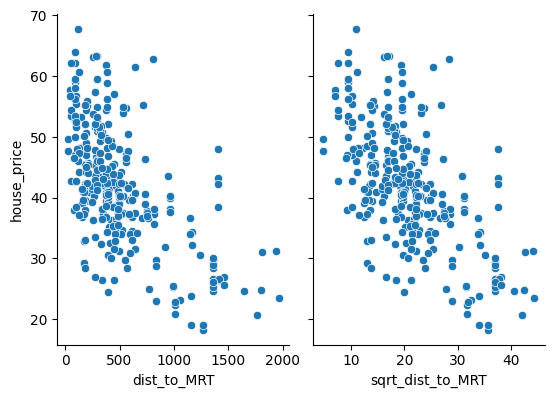

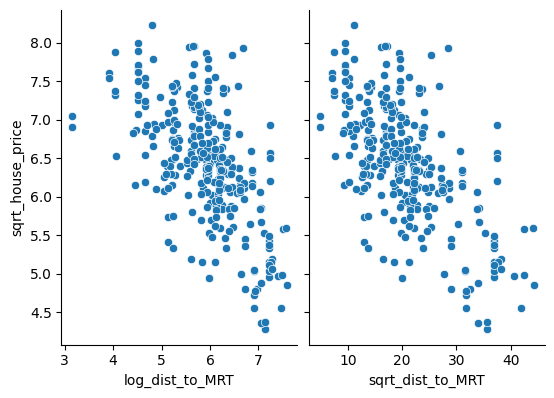

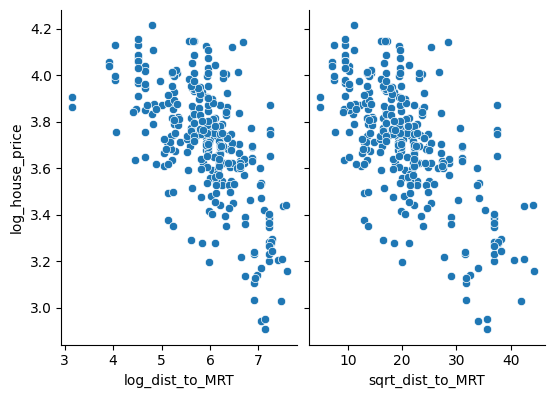

In [ ]:
df_4['sqrt_dist_to_MRT'] = np.sqrt(df_4['dist_to_MRT'])
df_4['sqrt_house_price'] = np.sqrt(df_4['house_price'])
df_4['log_dist_to_MRT'] = np.log(df_4['dist_to_MRT'])
df_4['log_house_price'] = np.log(df_4['house_price'])
p = sns.pairplot(df_4, x_vars=[ 'dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'house_price', size = 4, aspect=0.7)
p = sns.pairplot(df_4, x_vars=[ 'log_dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'sqrt_house_price', size = 4, aspect=0.7)
p = sns.pairplot(df_4, x_vars=[ 'log_dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'log_house_price', size = 4, aspect=0.7)

In [ ]:
df_max_scaled=df_4.copy()
from sklearn import preprocessing
min_max = preprocessing.MinMaxScaler()
scaled_df = min_max.fit_transform(df_max_scaled.values)
df_scaled = pd.DataFrame(scaled_df)

<Axes: >

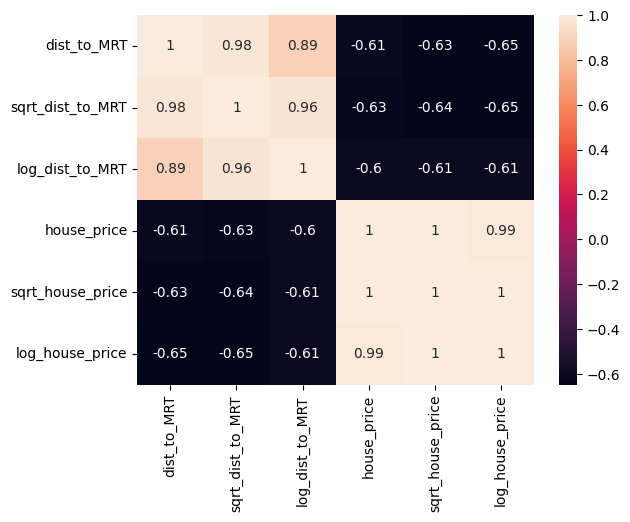

In [ ]:
column = ['dist_to_MRT','sqrt_dist_to_MRT','log_dist_to_MRT','house_price','sqrt_house_price','log_house_price']
data=df_4[column]
data.head()
corr = data.corr("pearson")

sns.heatmap(corr, annot=True)

In [ ]:
df_4

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price,sqrt_dist_to_MRT,sqrt_house_price,log_dist_to_MRT,log_house_price
0,1,2012,32.0,84.87882,10,24.98298,121.54024,37.9,9.212970,6.156298,4.441225,3.634951
1,2,2012,19.5,306.59470,9,24.98034,121.53951,42.2,17.509846,6.496153,5.725527,3.742420
2,3,2013,13.3,561.98450,5,24.98746,121.54391,47.3,23.706212,6.877500,6.331474,3.856510
3,4,2013,13.3,561.98450,5,24.98746,121.54391,54.8,23.706212,7.402702,6.331474,4.003690
4,5,2012,5.0,390.56840,5,24.97937,121.54245,43.1,19.762803,6.565059,5.967603,3.763523
...,...,...,...,...,...,...,...,...,...,...,...,...
406,407,2013,1.9,372.13860,7,24.97293,121.54026,40.5,19.290894,6.363961,5.919266,3.701302
410,411,2012,5.6,90.45606,9,24.97433,121.54310,50.0,9.510839,7.071068,4.504864,3.912023
411,412,2013,18.8,390.96960,7,24.97923,121.53986,40.6,19.772951,6.371813,5.968630,3.703768
412,413,2013,8.1,104.81010,5,24.96674,121.54067,52.5,10.237680,7.245688,4.652150,3.960813


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


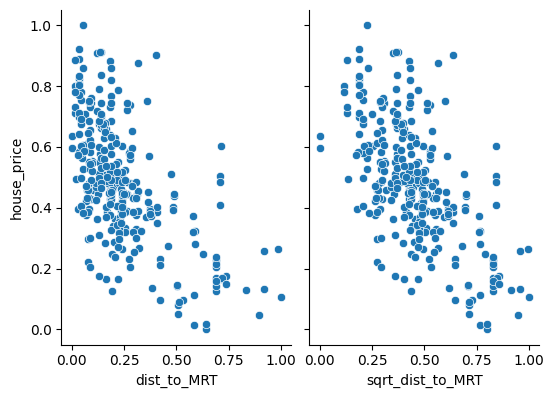

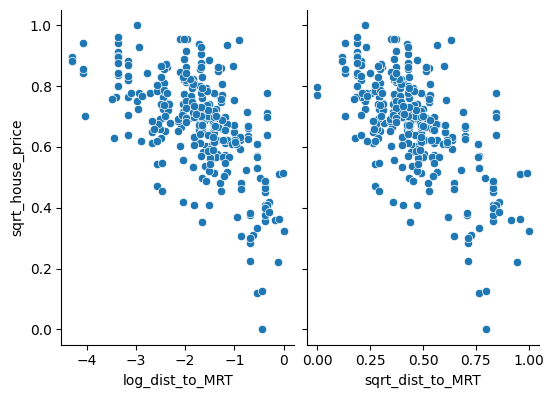

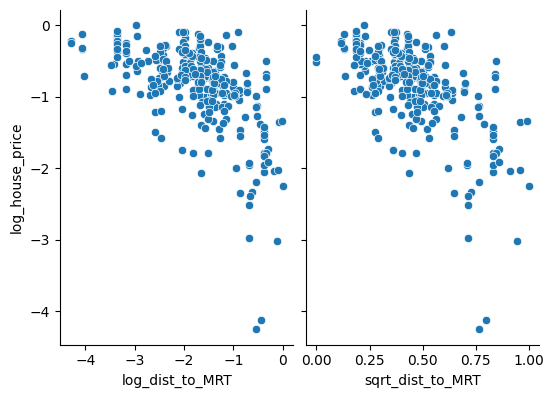

In [ ]:
new_names = ['No','trans_date','house_age','dist_to_MRT','conv_store','lat','long','house_price','sqrt_dist_to_MRT', 'sqrt_house_price', 'log_dist_to_MRT', 'log_house_price']
df_scaled = df_scaled.set_axis(new_names, axis='columns')
df_scaled['sqrt_dist_to_MRT'] = np.sqrt(df_scaled.dist_to_MRT)
df_scaled['sqrt_house_price'] = np.sqrt(df_scaled.house_price)
df_scaled['log_dist_to_MRT'] = np.log(df_scaled.dist_to_MRT)
df_scaled['log_house_price'] = np.log(df_scaled.house_price)
p = sns.pairplot(df_scaled, x_vars=['dist_to_MRT','sqrt_dist_to_MRT'], y_vars='house_price', size=4, aspect=0.7)
p = sns.pairplot(df_scaled, x_vars=['log_dist_to_MRT','sqrt_dist_to_MRT'], y_vars='sqrt_house_price', size=4, aspect=0.7)
p = sns.pairplot(df_scaled, x_vars=['log_dist_to_MRT','sqrt_dist_to_MRT'], y_vars='log_house_price', size=4, aspect=0.7)

<Axes: >

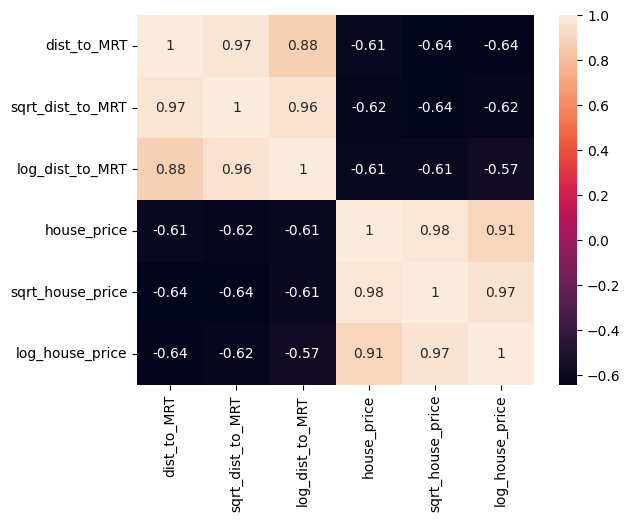

In [ ]:
column = ['dist_to_MRT','sqrt_dist_to_MRT','log_dist_to_MRT','house_price','sqrt_house_price','log_house_price']
data = df_scaled[column]
data.head()
corr = data.corr("pearson")

sns.heatmap(corr, annot=True)

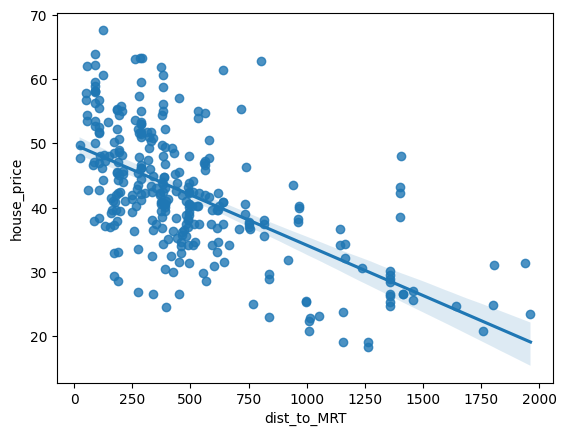

In [ ]:
sns.regplot(x='dist_to_MRT', y= 'house_price', data=df_4);

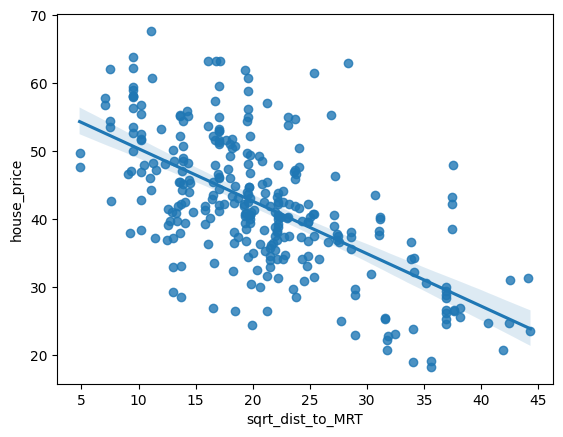

In [ ]:
sns.regplot(x='sqrt_dist_to_MRT', y= 'house_price', data=df_4);

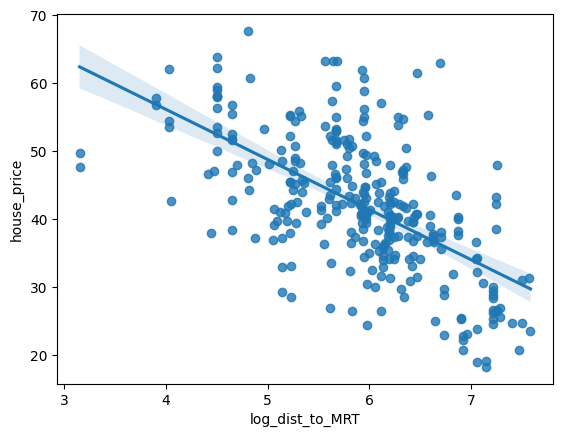

In [ ]:
sns.regplot(x='log_dist_to_MRT', y= 'house_price', data=df_4);

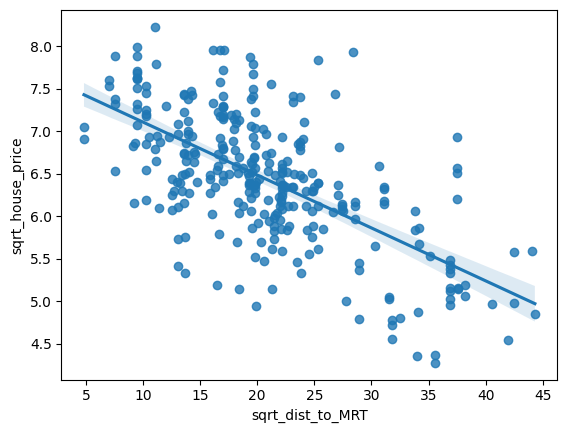

In [ ]:
sns.regplot(x='sqrt_dist_to_MRT', y= 'sqrt_house_price', data=df_4);

# **LINEAR REGRESSION 1**

In [ ]:
from sklearn.model_selection import train_test_split
X1 = df.drop(['house_price'],axis=1) # data fitur/prediktor
y1 = df.house_price # target
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1, test_size = 0.2,random_state = 0)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit (X1_train, y1_train)

LinearRegression()

In [ ]:
reg.coef_

array([-5.30413265e-03,  2.68096447e+00, -2.66453987e-01, -4.40560439e-03,
        1.11189597e+00,  2.33291255e+02, -1.39919126e+01])

In [ ]:
y1_pred = reg.predict(X1_test)
y1_pred

array([38.98583161, 13.104198  , 41.74054363, 12.06317213, 40.91304714,
       40.23775488, 41.00955577, 35.90941863, 49.80659265, 44.9922497 ,
       45.50474025, 42.4516471 , 38.14279633, 41.09032116, 46.07379506,
       37.37687329, 40.38034933, 41.01129854, 41.09404069, 41.71922144,
       49.56787771, 32.424555  , 38.41063178, 47.47261579, 45.78450396,
       42.23371425, 45.80987366, 26.54279937, 47.57416869, 20.42347795,
       42.8460876 , 33.56409693, 43.00413941, 37.89257859, 42.88023863,
       30.68985415, 47.8967069 , 40.19216462, 52.73414137,  7.51269689,
       51.22572211, 33.00475213, 33.41570795, 47.85450594, 14.86139178,
       43.82643854, 42.5369668 , 12.28884439, 34.34518906, 46.82947542,
       51.65908557, 40.36405957, 48.199612  , 24.92946369, 31.88365821,
       33.32607904, 48.45566043, 41.68045411, 43.35999212, 33.56459588,
       43.02618827, 43.76211504, 40.83283534, 46.73917491, 37.60934539,
       30.96462021, 11.25570729, 34.46751544, 47.7062734 , 41.72

In [ ]:
from sklearn.metrics import r2_score
print('r2 Score : ', r2_score(y1_test, y1_pred))

r2 Score :  0.6589431008263702


In [ ]:
from sklearn.model_selection import train_test_split
X2 = df_5.drop(['house_price'],axis=1) # data fitur/prediktor
y2 = df_5.house_price # target
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2, test_size = 0.2,random_state = 0)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit (X2_train, y2_train)

LinearRegression()

In [ ]:
reg.coef_

array([-3.26840104e-03,  2.44360461e+00, -3.07459429e-01, -8.56913143e-03,
        7.68811272e-01,  2.90993419e+02,  4.72412065e+01])

In [ ]:
y2_pred = reg.predict(X2_test)
y2_pred

array([42.13141006, 48.44287228, 15.3264644 , 42.96515335, 35.89352306,
       48.06901871, 35.20566989, 45.98119553, 13.55501409, 50.4263715 ,
       44.42756826, 29.28222737, 35.42452885, 39.60514845, 34.08583464,
       38.70057104, 45.09706554, 47.36608472, 28.21414764, 21.58727783,
       30.42032219, 42.45737389, 37.1700315 , 40.54148201, 41.7750299 ,
       26.70886437, 45.28500752, 43.01123335, 38.11892041, 54.76390934,
       43.24016173, 33.05985494, 19.84011004, 48.10213006, 28.04699653,
       48.38278521, 53.61742765, 43.03023376, 41.26933984, 24.89199485,
       43.13802565, 20.49162041, 48.21015549, 52.64128708, 25.02303565,
       39.79160312, 45.57790802, 38.22435953, 50.67070728, 26.14515616,
       45.13790213, 30.80852319, 28.01684129, 32.84819425, 51.49948328,
       41.31682996, 35.65732968, 41.15967638, 50.24680345, 48.34106491,
       27.55439516, 43.45618027, 42.41835675, 42.76660904, 38.05128799,
       39.94715225, 41.14252643, 33.47361154, 29.41357751, 46.41

In [ ]:
from sklearn.metrics import r2_score
print('r2 Score : ', r2_score(y2_test, y2_pred))

r2 Score :  0.5352156840005136


# **TRANSFORMATION**

<ipython-input-71-9975da4f4625>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_4['trans_dist_to_mrt'] =  np.log(df_4.dist_to_MRT.copy())
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


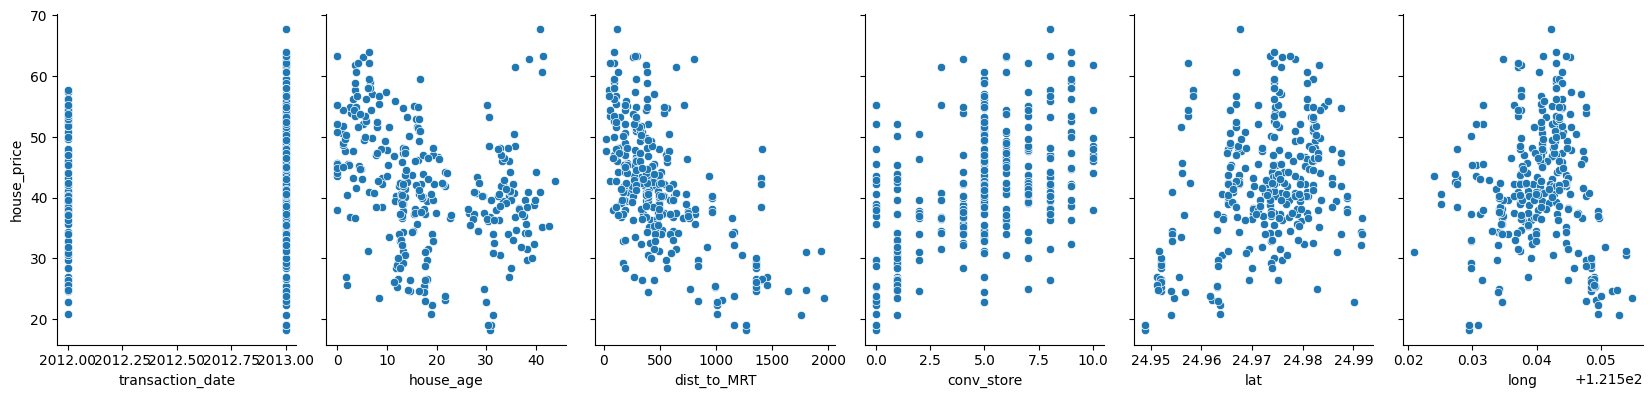

In [ ]:
df_4['trans_dist_to_mrt'] =  np.log(df_4.dist_to_MRT.copy())
p = sns.pairplot(df_4, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store',
       'lat', 'long'], y_vars= 'house_price', size=4, aspect=0.7)

array([<Axes: title={'center': 'dist_to_MRT'}>,
       <Axes: title={'center': 'house_price'}>,
       <Axes: title={'center': 'trans_dist_to_mrt'}>], dtype=object)

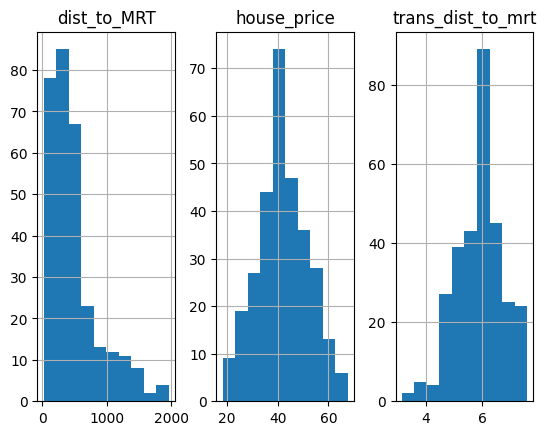

In [ ]:
fig, axes = plt.subplots(1,3)
df_4[['dist_to_MRT', 'house_price','trans_dist_to_mrt']].hist(ax = axes)

<Axes: xlabel='trans_dist_to_mrt', ylabel='house_price'>

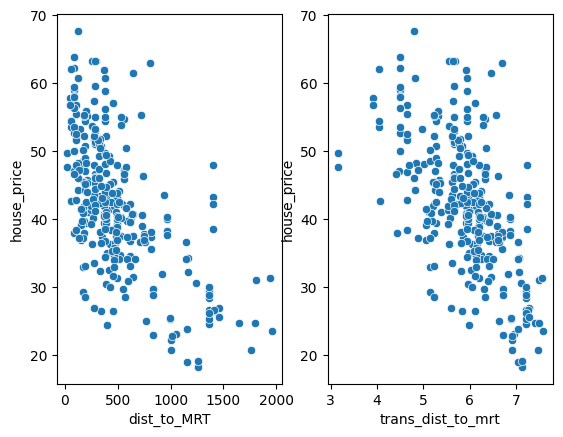

In [ ]:
fig, axes = plt.subplots(1, 2)
sns.scatterplot(data=df_4, x='dist_to_MRT', y = 'house_price', ax = axes[0])
sns.scatterplot(data=df_4, x='trans_dist_to_mrt', y = 'house_price', ax = axes[1])

<Axes: xlabel='trans_dist_to_mrt', ylabel='house_price'>

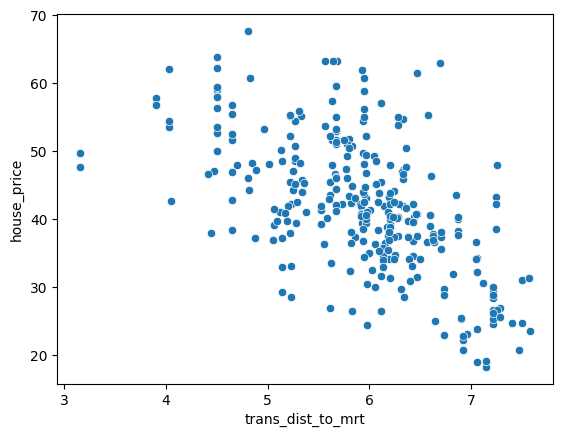

In [ ]:
sns.scatterplot(data=df_4, x = 'trans_dist_to_mrt', y = 'house_price')

# **# LINEAR REGRESSION 2**

In [ ]:
df_4.columns

Index(['No', 'transaction_date', 'house_age', 'dist_to_MRT', 'conv_store',
       'lat', 'long', 'house_price', 'sqrt_dist_to_MRT', 'sqrt_house_price',
       'log_dist_to_MRT', 'log_house_price', 'trans_dist_to_mrt'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_1 = df_4.drop(['No','house_price'],axis=1)
y_1 = df_4.house_price
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1,y_1, test_size = 0.05,random_state = 0)
reg_1 = LinearRegression()
reg_1.fit (X_1_train, y_1_train)
print(f'reg_1.coef_{reg_1.coef_}')
y_1_pred = reg_1.predict(X_1_test)
print('r2 Score model reg_1 : ', r2_score(y_1_test, y_1_pred))

reg_1.coef_[-8.38744817e-03  1.33253739e-03 -4.67509961e-05 -1.64624785e-03
 -3.35389781e-01  2.51283172e+00  8.20260387e-03  2.46373631e+01
 -2.04407718e-02 -3.72628117e+01 -2.04407718e-02]
r2 Score model reg_1 :  0.9999043194447489


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_1 = df_4.drop(['No', 'transaction_date', 'lat', 'long', 'house_price', 'trans_dist_to_mrt'], axis=1)
X_1 = df_4[['house_age', 'dist_to_MRT', 'conv_store']].copy()
X_2 = df_4.drop(['No', 'transaction_date', 'lat', 'long', 'dist_to_MRT', 'house_price'], axis=1)
X_2 = df_4[['house_age', 'trans_dist_to_mrt', 'conv_store']].copy()
y = df_4.house_price

X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1,y, test_size=0.05, random_state=0)
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2,y, test_size=0.05, random_state=0)

reg_1 = LinearRegression()
reg_1.fit (X_1_train, y_1_train)
reg_2 = LinearRegression()
reg_2.fit (X_2_train, y_2_train)

print(f'reg_1.coef_{reg_1.coef_}')
y_1_pred = reg_1.predict(X_1_test)
print('r2 Score model reg_1 : ', r2_score(y_1_test, y_1_pred))

print(f'reg_2.coef_{reg_1.coef_}')
y_2_pred = reg_2.predict(X_2_test)
print('r2 Score model reg_2 : ', r2_score(y_2_test,y_2_pred))

reg_1.coef_[-0.26514379 -0.01302213  0.63801432]
r2 Score model reg_1 :  -0.3217054670800772
reg_2.coef_[-0.26514379 -0.01302213  0.63801432]
r2 Score model reg_2 :  -0.3071364614004062


<ipython-input-78-e75b3f751c41>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_4['sqrt_dist_to_MRT'] = np.sqrt(df_4['dist_to_MRT'])
<ipython-input-78-e75b3f751c41>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_4['sqrt_house_price'] = np.sqrt(df_4['house_price'])
<ipython-input-78-e75b3f751c41>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

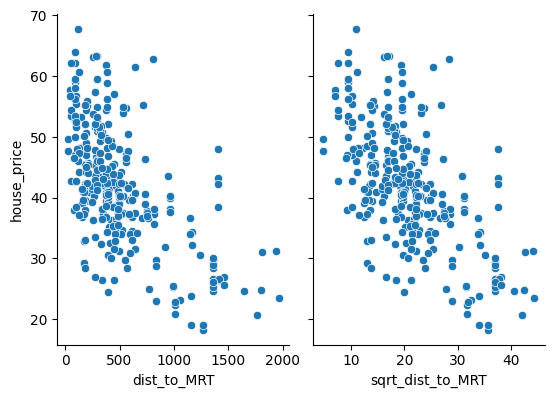

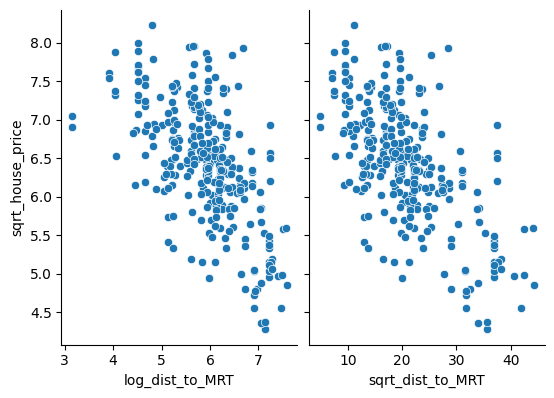

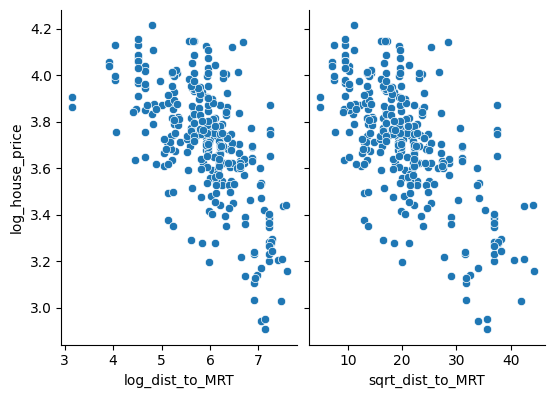

In [ ]:
df_4['sqrt_dist_to_MRT'] = np.sqrt(df_4['dist_to_MRT'])
df_4['sqrt_house_price'] = np.sqrt(df_4['house_price'])
df_4['log_dist_to_MRT'] = np.log(df_4['dist_to_MRT'])
df_4['log_house_price'] = np.log(df_4['house_price'])
p = sns.pairplot(df_4, x_vars=[ 'dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'house_price', size = 4, aspect=0.7)
p = sns.pairplot(df_4, x_vars=[ 'log_dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'sqrt_house_price', size = 4, aspect=0.7)
p = sns.pairplot(df_4, x_vars=[ 'log_dist_to_MRT', 'sqrt_dist_to_MRT'], y_vars= 'log_house_price', size = 4, aspect=0.7)

# **MLP**

In [ ]:
df

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
0,1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013,8.1,104.81010,5,24.96674,121.54067,52.5


In [ ]:
df.iloc[:,-1]

0      37.9
1      42.2
2      47.3
3      54.8
4      43.1
       ... 
409    15.4
410    50.0
411    40.6
412    52.5
413    63.9
Name: house_price, Length: 414, dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                414 non-null    int64  
 1   transaction_date  414 non-null    int64  
 2   house_age         414 non-null    float64
 3   dist_to_MRT       414 non-null    float64
 4   conv_store        414 non-null    int64  
 5   lat               414 non-null    float64
 6   long              414 non-null    float64
 7   house_price       414 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 26.0 KB

Membuat neural network dengan aktivasi relu


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error: 56.67920299280019
Mean Absolute Error: 5.1222366693423025
R-squared Score: 0.6688569891076959



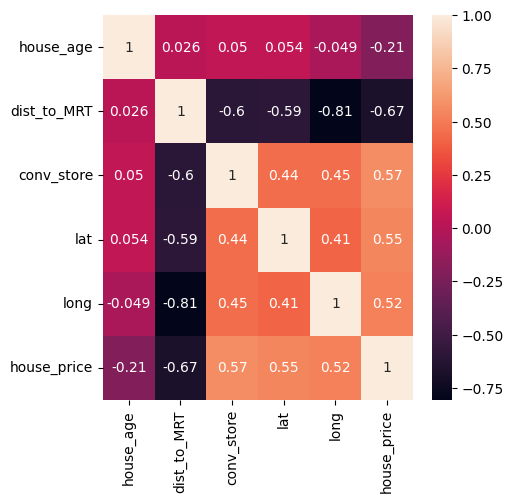

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df.info()
corr = df.drop(['No','transaction_date'],axis=1).corr()
plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True)

# Bagi data Anda menjadi set pelatihan dan pengujian
X = df.drop(['No','transaction_date','house_price'],axis=1)
Y = df.iloc[:,-1]
sc=StandardScaler()
X=sc.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Tentukan parameter hiperparameter jaringan saraf Anda
params = {
    'hidden_layer_sizes': (3,2),  # Sesuaikan jumlah neuron di setiap lapisan tersembunyi
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,  # Kekuatan regularisasi
    'batch_size': 10,
    'random_state': 0,
    'tol': 1e-4,
    'momentum': 0.9,  # Momentum
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 50,
    'shuffle': True,
    'n_iter_no_change': 50,
    'verbose': False
}

# Buat MLPRegressor
print("\nMembuat neural network dengan aktivasi relu")
net = MLPRegressor(**params)

# Latih NN pada data training
net.fit(X_train, Y_train)

# Lakukan prediksi pada data test
Y_pred_net = net.predict(X_test)

# Evaluasi kinerja model
mse = mean_squared_error(Y_test, Y_pred_net)
mae = mean_absolute_error(Y_test, Y_pred_net)
r2 = r2_score(Y_test, Y_pred_net)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}\n")

In [ ]:
df_4

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price,sqrt_dist_to_MRT,sqrt_house_price,log_dist_to_MRT,log_house_price,trans_dist_to_mrt
0,1,2012,32.0,84.87882,10,24.98298,121.54024,37.9,9.212970,6.156298,4.441225,3.634951,4.441225
1,2,2012,19.5,306.59470,9,24.98034,121.53951,42.2,17.509846,6.496153,5.725527,3.742420,5.725527
2,3,2013,13.3,561.98450,5,24.98746,121.54391,47.3,23.706212,6.877500,6.331474,3.856510,6.331474
3,4,2013,13.3,561.98450,5,24.98746,121.54391,54.8,23.706212,7.402702,6.331474,4.003690,6.331474
4,5,2012,5.0,390.56840,5,24.97937,121.54245,43.1,19.762803,6.565059,5.967603,3.763523,5.967603
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,407,2013,1.9,372.13860,7,24.97293,121.54026,40.5,19.290894,6.363961,5.919266,3.701302,5.919266
410,411,2012,5.6,90.45606,9,24.97433,121.54310,50.0,9.510839,7.071068,4.504864,3.912023,4.504864
411,412,2013,18.8,390.96960,7,24.97923,121.53986,40.6,19.772951,6.371813,5.968630,3.703768,5.968630
412,413,2013,8.1,104.81010,5,24.96674,121.54067,52.5,10.237680,7.245688,4.652150,3.960813,4.652150


In [ ]:
df_4.iloc[:,-6]

0      37.9
1      42.2
2      47.3
3      54.8
4      43.1
       ... 
406    40.5
410    50.0
411    40.6
412    52.5
413    63.9
Name: house_price, Length: 303, dtype: float64

<class 'pandas.core.frame.DataFrame'>
Int64Index: 303 entries, 0 to 413
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No                 303 non-null    int64  
 1   transaction_date   303 non-null    int64  
 2   house_age          303 non-null    float64
 3   dist_to_MRT        303 non-null    float64
 4   conv_store         303 non-null    int64  
 5   lat                303 non-null    float64
 6   long               303 non-null    float64
 7   house_price        303 non-null    float64
 8   sqrt_dist_to_MRT   303 non-null    float64
 9   sqrt_house_price   303 non-null    float64
 10  log_dist_to_MRT    303 non-null    float64
 11  log_house_price    303 non-null    float64
 12  trans_dist_to_mrt  303 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 33.1 KB

Membuat neural network dengan aktivasi relu


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error: 44.23708086449086
Mean Absolute Error: 4.837376947271757
R-squared Score: 0.5776186904752213



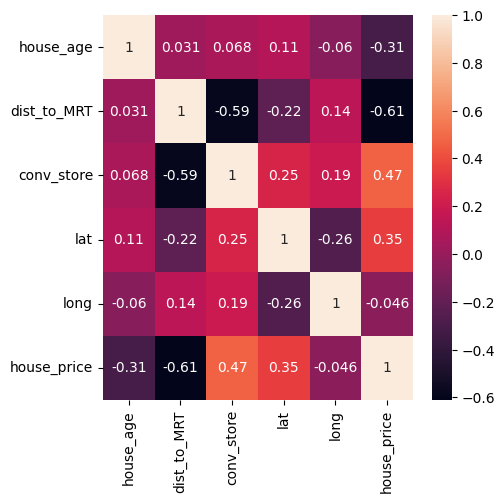

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df_4.info()
corr = df_4.drop(['No','transaction_date','sqrt_dist_to_MRT',	'sqrt_house_price',	'log_dist_to_MRT',	'log_house_price'	,'trans_dist_to_mrt'],axis=1).corr()
plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True)

# Bagi data Anda menjadi set pelatihan dan pengujian
X = df_4.drop(['No','transaction_date','house_price','No','transaction_date','sqrt_dist_to_MRT',	'sqrt_house_price',	'log_dist_to_MRT',	'log_house_price'	,'trans_dist_to_mrt'],axis=1)
Y = df_4.iloc[:,-6]
sc=StandardScaler()
X=sc.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Tentukan parameter hiperparameter jaringan saraf Anda
params = {
    'hidden_layer_sizes': (3,2),  # Sesuaikan jumlah neuron di setiap lapisan tersembunyi
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,  # Kekuatan regularisasi
    'batch_size': 10,
    'random_state': 0,
    'tol': 1e-4,
    'momentum': 0.9,  # Momentum
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 50,
    'shuffle': True,
    'n_iter_no_change': 50,
    'verbose': False
}

# Buat MLPRegressor
print("\nMembuat neural network dengan aktivasi relu")
net = MLPRegressor(**params)

# Latih NN pada data training
net.fit(X_train, Y_train)

# Lakukan prediksi pada data test
Y_pred_net = net.predict(X_test)

# Evaluasi kinerja model
mse = mean_squared_error(Y_test, Y_pred_net)
mae = mean_absolute_error(Y_test, Y_pred_net)
r2 = r2_score(Y_test, Y_pred_net)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}\n")

In [ ]:
df_5

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
0,1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
408,409,2013,18.5,2175.74400,3,24.96330,121.51243,28.1
410,411,2012,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013,8.1,104.81010,5,24.96674,121.54067,52.5


<class 'pandas.core.frame.DataFrame'>
Int64Index: 371 entries, 0 to 413
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                371 non-null    int64  
 1   transaction_date  371 non-null    int64  
 2   house_age         371 non-null    float64
 3   dist_to_MRT       371 non-null    float64
 4   conv_store        371 non-null    int64  
 5   lat               371 non-null    float64
 6   long              371 non-null    float64
 7   house_price       371 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 26.1 KB

Membuat neural network dengan aktivasi relu


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error: 49.09353201494105
Mean Absolute Error: 5.324098694099781
R-squared Score: 0.6503658722008132



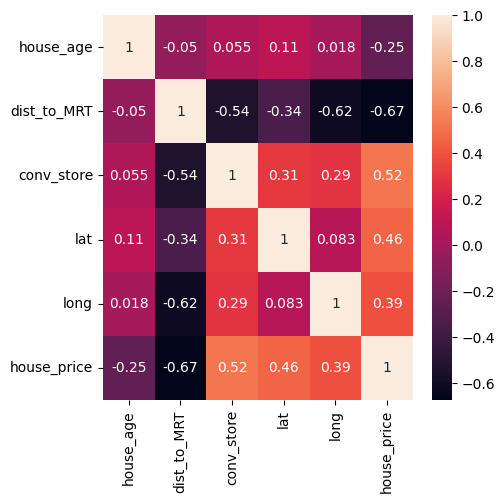

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df_5.info()
corr = df_5.drop(['No','transaction_date'],axis=1).corr()
plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True)

# Bagi data Anda menjadi set pelatihan dan pengujian
X = df_5.drop(['No','transaction_date','house_price'],axis=1)
Y = df_5.iloc[:,-1]
sc=StandardScaler()
X=sc.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Tentukan parameter hiperparameter jaringan saraf Anda
params = {
    'hidden_layer_sizes': (3,2),  # Sesuaikan jumlah neuron di setiap lapisan tersembunyi
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,  # Kekuatan regularisasi
    'batch_size': 10,
    'random_state': 0,
    'tol': 1e-4,
    'momentum': 0.9,  # Momentum
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 50,
    'shuffle': True,
    'n_iter_no_change': 50,
    'verbose': False
}

# Buat MLPRegressor
print("\nMembuat neural network dengan aktivasi relu")
net = MLPRegressor(**params)

# Latih NN pada data training
net.fit(X_train, Y_train)

# Lakukan prediksi pada data test
Y_pred_net = net.predict(X_test)

# Evaluasi kinerja model
mse = mean_squared_error(Y_test, Y_pred_net)
mae = mean_absolute_error(Y_test, Y_pred_net)
r2 = r2_score(Y_test, Y_pred_net)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}\n")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 303 entries, 0 to 413
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No                 303 non-null    int64  
 1   transaction_date   303 non-null    int64  
 2   house_age          303 non-null    float64
 3   dist_to_MRT        303 non-null    float64
 4   conv_store         303 non-null    int64  
 5   lat                303 non-null    float64
 6   long               303 non-null    float64
 7   house_price        303 non-null    float64
 8   sqrt_dist_to_MRT   303 non-null    float64
 9   sqrt_house_price   303 non-null    float64
 10  log_dist_to_MRT    303 non-null    float64
 11  log_house_price    303 non-null    float64
 12  trans_dist_to_mrt  303 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 33.1 KB

Membuat neural network dengan aktivasi relu


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error: 60.75340896239825
Mean Absolute Error: 5.64659886995644
R-squared Score: 0.22738607569941627



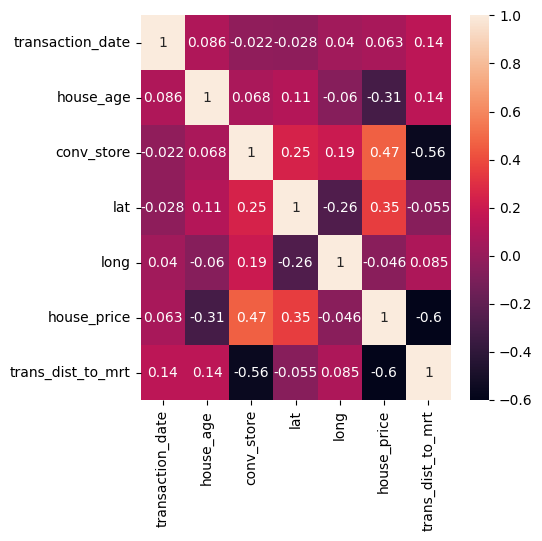

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df_4.info()
corr = df_4.drop(['No','dist_to_MRT','sqrt_dist_to_MRT', 'sqrt_house_price', 'log_dist_to_MRT', 'log_house_price'	],axis=1).corr()
plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True)

# Bagi data Anda menjadi set pelatihan dan pengujian
X = df_4.drop(['No','dist_to_MRT','sqrt_dist_to_MRT', 'sqrt_house_price', 'log_dist_to_MRT', 'log_house_price','house_price'],axis=1)
Y = df_4.iloc[:,-6]
sc=StandardScaler()
X=sc.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Tentukan parameter hiperparameter jaringan saraf Anda
params = {
    'hidden_layer_sizes': (3,2),  # Sesuaikan jumlah neuron di setiap lapisan tersembunyi
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,  # Kekuatan regularisasi
    'batch_size': 10,
    'random_state': 0,
    'tol': 1e-4,
    'momentum': 0.9,  # Momentum
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 50,
    'shuffle': True,
    'n_iter_no_change': 50,
    'verbose': False
}

# Buat MLPRegressor
print("\nMembuat neural network dengan aktivasi relu")
net = MLPRegressor(**params)

# Latih NN pada data training
net.fit(X_train, Y_train)

# Lakukan prediksi pada data test
Y_pred_net = net.predict(X_test)

# Evaluasi kinerja model
mse = mean_squared_error(Y_test, Y_pred_net)
mae = mean_absolute_error(Y_test, Y_pred_net)
r2 = r2_score(Y_test, Y_pred_net)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}\n")

# **PREDICTION**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Ganti path dengan direktori yang Anda inginkan
directory = "/content/drive/MyDrive/YourDirectory"

if not os.path.exists(directory):
    os.makedirs(directory)

import pickle
print("Saving")
path = "/content/drive/MyDrive/YourDirectory/realestate.sav"
pickle.dump(net, open(path, "wb"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving


In [ ]:
import pickle

# Muat model dari file pickle
with open('/content/drive/MyDrive/YourDirectory/realestate.sav', 'rb') as file:
    loaded_model = pickle.load(file)


In [ ]:
import numpy as np

# Fungsi untuk memprediksi harga rumah dengan model MLP
def predict_price_mlp(transaction_date, house_age, dist_to_MRT, conv_store, lat, long):
    # Persiapkan data input dengan format yang sesuai dengan model MLP
    input_data = [[transaction_date, house_age, dist_to_MRT, conv_store, lat, long]]

    # Lakukan prediksi dengan model MLP yang sudah dilatih (loaded_model)
    predicted_price = loaded_model.predict(input_data)

    return predicted_price[0]

In [ ]:
predict_price_mlp(2012, 19.5, 306.59470	, 9, 24.98034	, 121.53951)

4245.246808266924

In [ ]:
df_5

,No,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
0,1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
408,409,2013,18.5,2175.74400,3,24.96330,121.51243,28.1
410,411,2012,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013,8.1,104.81010,5,24.96674,121.54067,52.5
